# Bank Customer Churn — Analysis & Modelling

**Business problem.** A European retail bank is losing ~20% of its customers. Retention
budgets are finite, so the bank needs to know **which customers are likely to leave**
and, just as importantly, **why** — so outreach can be targeted rather than sprayed.

**Dataset.** `Churn_Modelling.csv` — 10,000 customers, 14 raw columns, target `Exited`
(1 = churned). Classes are imbalanced (~20% churn), so accuracy is a misleading metric;
this notebook uses **ROC-AUC** and **PR-AUC** throughout.

**Approach (mirrors the reference repo's flow, adapted to the bank data):**
1. Inspection with reusable helpers (`check_data`, `grab_col_names`)
2. Data-quality audit → cleaning
3. EDA — churn by segment, with visuals
4. Outlier handling (IQR winsorization) & correlation
5. Feature engineering (bank-specific, hypothesis-driven)
6. Modelling — DecisionTree, RandomForest, XGBoost, LightGBM, CatBoost, and a
   **Stacking ensemble**, with **SMOTE applied inside the CV folds** to avoid leakage
7. Model selection, interpretation, and a saved artifact for the API

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
RANDOM = 42

from feature_engineering import (check_data, grab_col_names, missing_values_table,
                                 check_outlier, replace_with_thresholds,
                                 clean, add_features, build_model_frame, NUM_COLS_TO_SCALE)

df = pd.read_csv("../data/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. First look — `check_data()`

In [2]:
check_data(df)

-------------------- SHAPE --------------------
(10000, 14)
-------------------- DTYPES --------------------
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
-------------------- HEAD --------------------
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
0          1    15634602  Hargrave          619    France  Female   42       2       0.00              1          1               1        101348.88       1
1          2    15647311      Hill          608     Spain  Female   41       1   83807.86              1          0               1       

## 2. Column typing — `grab_col_names()`
Automatically splits columns into categorical, numeric, and high-cardinality (cardinal) groups. `Surname` is correctly flagged as cardinal — an identifier to drop, not encode.

In [3]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations : 10000
Variables    : 14
cat_cols     : 6 -> ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']
num_cols     : 8 -> ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
cat_but_car  : 0 -> []


## 3. Data-quality audit
Never model before knowing what you're modelling on.

In [4]:
print("Duplicate rows :", df.duplicated().sum())
print("Missing values :", int(df.isnull().sum().sum()))
print("Geography      :", sorted(df.Geography.unique()))
print("Gender         :", sorted(df.Gender.unique()))
print(f"Churn rate     : {df.Exited.mean():.2%}  ({df.Exited.sum()} of {len(df)})")
print(f"Zero-balance   : {(df.Balance==0).mean():.1%} of customers  (a real segment, not an error)")
print(f"\nNaive 'nobody churns' accuracy would be {1-df.Exited.mean():.2%} while catching ZERO churners")
print("-> that's exactly why we optimise ROC-AUC / PR-AUC, not accuracy.")

Duplicate rows : 0
Missing values : 0
Geography      : ['France', 'Germany', 'Spain']
Gender         : ['Female', 'Male']
Churn rate     : 20.37%  (2037 of 10000)
Zero-balance   : 36.2% of customers  (a real segment, not an error)

Naive 'nobody churns' accuracy would be 79.63% while catching ZERO churners
-> that's exactly why we optimise ROC-AUC / PR-AUC, not accuracy.


## 4. Cleaning
Drop identifiers (no signal, leakage risk), remove duplicates, standardise categorical text.

In [5]:
df = clean(df)
print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 5. EDA — who churns?
Churn rate by segment. This is where the insight lives, not just the charts.

In [6]:
def churn_by(col):
    g = df.groupby(col)["Exited"].agg(["mean", "count"])
    g.columns = ["churn_rate", "customers"]
    g["churn_rate"] = (g["churn_rate"] * 100).round(1)
    return g.sort_values("churn_rate", ascending=False)

overall = df.Exited.mean() * 100
print(f"Baseline churn rate: {overall:.1f}%\n")
for col in ["Geography", "Gender", "NumOfProducts", "IsActiveMember", "HasCrCard"]:
    print(f"--- {col} ---"); print(churn_by(col).to_string()); print()

Baseline churn rate: 20.4%

--- Geography ---
           churn_rate  customers
Geography                       
Germany          32.4       2509
Spain            16.7       2477
France           16.2       5014

--- Gender ---
        churn_rate  customers
Gender                       
Female        25.1       4543
Male          16.5       5457

--- NumOfProducts ---
               churn_rate  customers
NumOfProducts                       
4                   100.0         60
3                    82.7        266
1                    27.7       5084
2                     7.6       4590

--- IsActiveMember ---
                churn_rate  customers
IsActiveMember                       
0                     26.9       4849
1                     14.3       5151

--- HasCrCard ---
           churn_rate  customers
HasCrCard                       
0                20.8       2945
1                20.2       7055



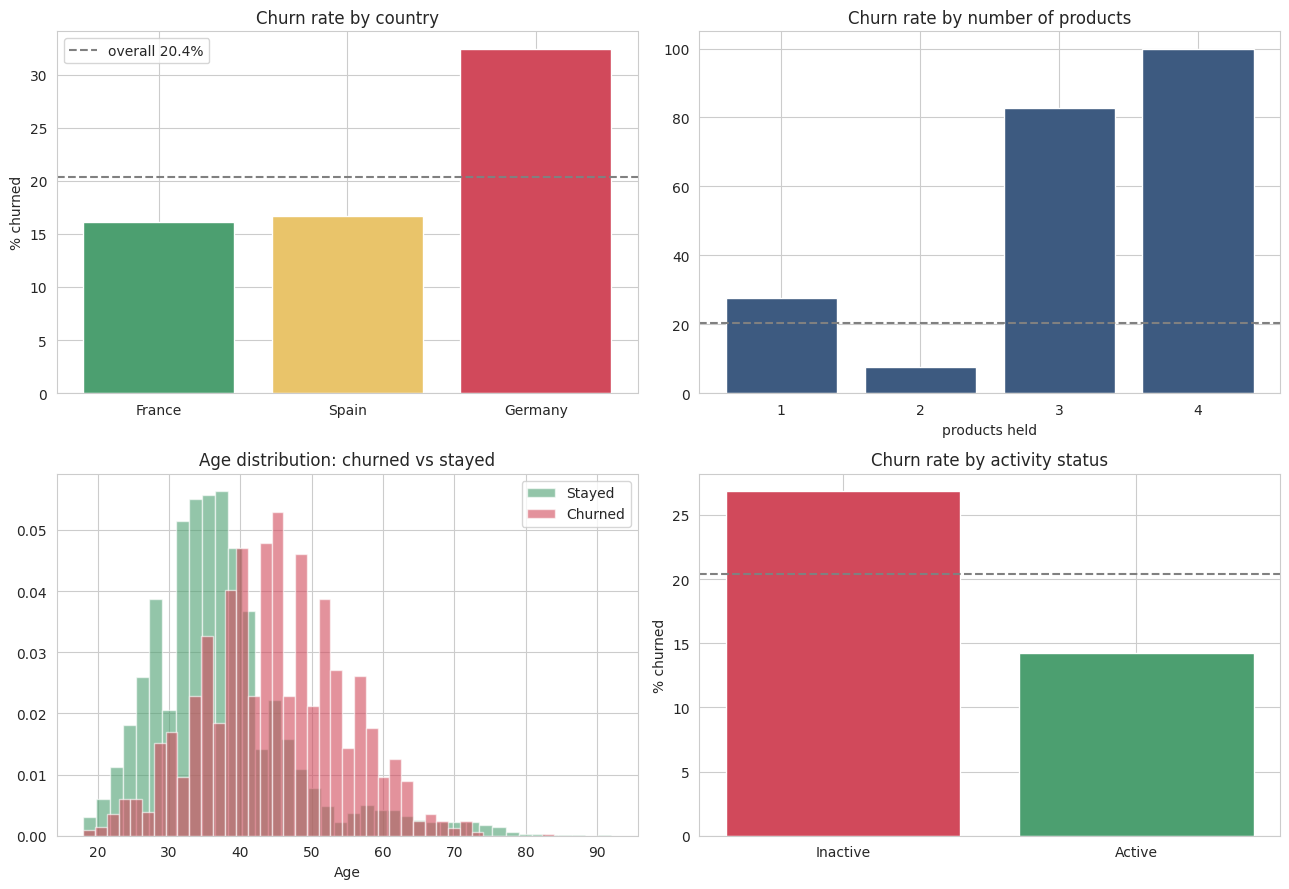

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

g = df.groupby("Geography")["Exited"].mean().sort_values() * 100
axes[0,0].bar(g.index, g.values, color=["#4C9F70", "#E9C46A", "#D1495B"])
axes[0,0].axhline(overall, ls="--", color="gray", label=f"overall {overall:.1f}%")
axes[0,0].set_title("Churn rate by country"); axes[0,0].set_ylabel("% churned"); axes[0,0].legend()

g = df.groupby("NumOfProducts")["Exited"].mean() * 100
axes[0,1].bar(g.index.astype(str), g.values, color="#3D5A80")
axes[0,1].axhline(overall, ls="--", color="gray")
axes[0,1].set_title("Churn rate by number of products"); axes[0,1].set_xlabel("products held")

axes[1,0].hist(df[df.Exited==0]["Age"], bins=40, alpha=0.6, label="Stayed", color="#4C9F70", density=True)
axes[1,0].hist(df[df.Exited==1]["Age"], bins=40, alpha=0.6, label="Churned", color="#D1495B", density=True)
axes[1,0].set_title("Age distribution: churned vs stayed"); axes[1,0].set_xlabel("Age"); axes[1,0].legend()

g = df.groupby("IsActiveMember")["Exited"].mean() * 100
axes[1,1].bar(["Inactive", "Active"], g.values, color=["#D1495B", "#4C9F70"])
axes[1,1].axhline(overall, ls="--", color="gray")
axes[1,1].set_title("Churn rate by activity status"); axes[1,1].set_ylabel("% churned")

plt.tight_layout(); plt.show()

**What the EDA already tells us**
- **Number of products** is the strongest single signal — customers with 3–4 products churn dramatically more than those with 1–2 (counter-intuitive; worth flagging to the business).
- **Germany** churns at roughly double the rate of France/Spain — a market-specific problem.
- **Inactive** members churn far more than active ones — and unlike age or geography, activity is *actionable*.
- **Churners are older** on average.

## 6. Outlier handling (IQR winsorization)
Cap genuinely extreme values so they don't distort the models, using the repo's threshold approach on a wider 5/95 fence.

In [8]:
# numeric columns that remain after cleaning (IDs were dropped above)
num_cols = [c for c in ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"] if c in df.columns]
for col in num_cols:
    print(f"{col:<18} outliers present: {check_outlier(df, col)}")
for col in num_cols:
    replace_with_thresholds(df, col)
print("\nAfter winsorization:")
for col in num_cols:
    print(f"{col:<18} outliers present: {check_outlier(df, col)}")

CreditScore        outliers present: False
Age                outliers present: False
Tenure             outliers present: False
Balance            outliers present: False
EstimatedSalary    outliers present: False

After winsorization:
CreditScore        outliers present: False
Age                outliers present: False
Tenure             outliers present: False
Balance            outliers present: False
EstimatedSalary    outliers present: False


## 7. Correlation analysis

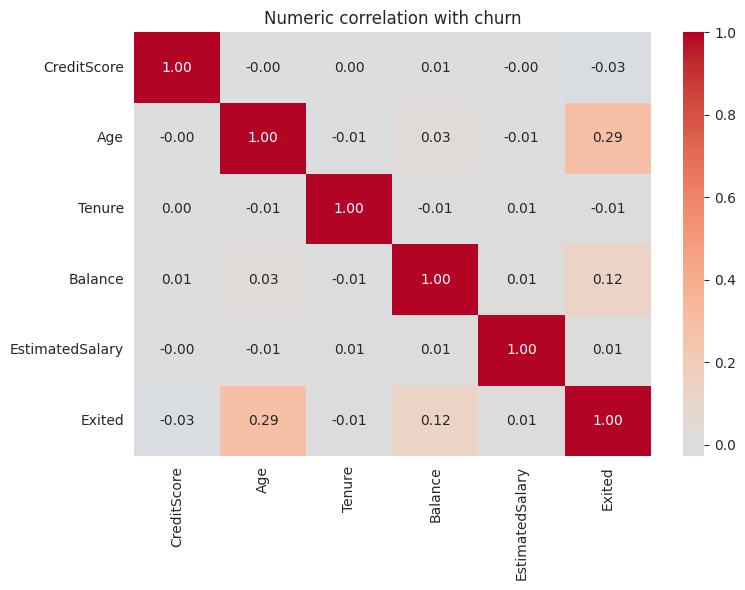

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ["Exited"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric correlation with churn"); plt.tight_layout(); plt.show()

## 8. Feature engineering
Each new feature carries a stated hypothesis. (The Telco repo's `gender × service`
interactions don't exist here, so these are the bank-appropriate equivalents.)

| Feature | Hypothesis |
|---|---|
| `ZeroBalance` | A zero balance is a distinct behavioural state |
| `BalanceToSalary` | Balance relative to income beats raw balance |
| `ProductsPerTenure` | Adoption speed, not just total products held |
| `EngagementScore` | Active **and** card-holding differs from either alone |
| `AgeBucket` | Life stage matters more than exact age |

In [10]:
df = add_features(df)
print("New features created:\n")
print("EngagementScore (0=neither, 1=one, 2=both):")
print(churn_by("EngagementScore").to_string())
print("\nAgeBucket:")
print(churn_by("AgeBucket").to_string())

New features created:

EngagementScore (0=neither, 1=one, 2=both):
                 churn_rate  customers
EngagementScore                       
0                      25.7       1401
1                      23.9       4992
2                      13.4       3607

AgeBucket:
           churn_rate  customers
AgeBucket                       
51-60            56.2        797
41-50            34.0       2320
60+              24.8        464
31-40            12.1       4451
18-30             7.5       1968


## 9. Encoding → modelling matrix
`build_model_frame` re-runs clean → engineer → one-hot encode from the raw file, returning the exact `X`, `y` used for training.

In [11]:
raw = pd.read_csv("../data/Churn_Modelling.csv")
X, y, feature_names = build_model_frame(raw)
print("X:", X.shape, "| features:", feature_names)

X: (10000, 15) | features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'ZeroBalance', 'BalanceToSalary', 'ProductsPerTenure', 'EngagementScore', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


## 10. Modelling

**Imbalance → SMOTE, applied leakage-safe.** SMOTE synthesises minority-class
examples, but it must only ever see *training* data. On the holdout split we resample
`X_train` alone; in cross-validation we wrap SMOTE in an `imblearn` pipeline so it runs
**inside each fold** — never on data the model is scored against.

**Model roster (the full repo stack):** DecisionTree, RandomForest, XGBoost, LightGBM,
CatBoost, and a **Stacking ensemble** (all five as base learners, Logistic Regression as
the meta-learner that learns how much to trust each one).

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, RocCurveDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_pipeline

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM)
X_res, y_res = SMOTE(random_state=RANDOM).fit_resample(X_tr, y_tr)
print("Train class balance before SMOTE:", np.bincount(y_tr), "-> after:", np.bincount(y_res))

def make_models():
    return {
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM),
        "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, n_jobs=-1, random_state=RANDOM),
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, eval_metric="logloss", n_jobs=-1, random_state=RANDOM),
        "LightGBM": LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, n_jobs=-1, random_state=RANDOM, verbose=-1),
        "CatBoost": CatBoostClassifier(iterations=300, depth=5, learning_rate=0.1, verbose=0, random_seed=RANDOM),
    }

def build_stack():
    m = make_models()
    return StackingClassifier(
        estimators=[("rf", m["Random Forest"]), ("xgb", m["XGBoost"]), ("lgbm", m["LightGBM"]),
                    ("cat", m["CatBoost"]), ("dt", m["Decision Tree"])],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM),
        cv=5, stack_method="predict_proba", n_jobs=-1)

Train class balance before SMOTE: [6370 1630] -> after: [6370 6370]


### 10a. Holdout evaluation (all models trained on SMOTE-resampled data)

In [13]:
models = make_models(); models["Stacking Ensemble"] = build_stack()
holdout, fitted = {}, {}
for name, mdl in models.items():
    mdl.fit(X_res, y_res)
    proba = mdl.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_te, pred)
    holdout[name] = {"ROC-AUC": roc_auc_score(y_te, proba),
                     "PR-AUC": average_precision_score(y_te, proba),
                     "Precision": cm[1,1]/max(cm[:,1].sum(),1),
                     "Recall": cm[1,1]/cm[1].sum()}
    fitted[name] = mdl
pd.DataFrame(holdout).T.round(3).sort_values("ROC-AUC", ascending=False)

,ROC-AUC,PR-AUC,Precision,Recall
CatBoost,0.865,0.715,0.678,0.575
Stacking Ensemble,0.857,0.701,0.648,0.592
LightGBM,0.852,0.692,0.683,0.541
XGBoost,0.851,0.693,0.712,0.553
Random Forest,0.839,0.615,0.525,0.646
Decision Tree,0.815,0.558,0.457,0.676


### 10b. Repeated Stratified K-Fold CV — SMOTE inside every fold
The number to trust: it averages over multiple shuffles so no single lucky split can flatter a model.

In [14]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=1)
cv_scores = {}
for name, mdl in make_models().items():
    pipe = imb_pipeline(SMOTE(random_state=RANDOM), mdl)
    s = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = (s.mean(), s.std())
    print(f"{name:<16} ROC-AUC {s.mean():.3f} +/- {s.std():.3f}")

# stacking evaluated with a single 5-fold to keep runtime reasonable
skf = StratifiedKFold(5, shuffle=True, random_state=1)
s = cross_val_score(imb_pipeline(SMOTE(random_state=RANDOM), build_stack()), X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
cv_scores["Stacking Ensemble"] = (s.mean(), s.std())
print(f"{'Stacking Ensemble':<16} ROC-AUC {s.mean():.3f} +/- {s.std():.3f}")

Decision Tree    ROC-AUC 0.807 +/- 0.011


Random Forest    ROC-AUC 0.831 +/- 0.006


XGBoost          ROC-AUC 0.852 +/- 0.008


LightGBM         ROC-AUC 0.850 +/- 0.009


CatBoost         ROC-AUC 0.858 +/- 0.006


Stacking Ensemble ROC-AUC 0.853 +/- 0.006


### 10c. Pick the winner (by cross-validated ROC-AUC)

Best model: CatBoost  (CV ROC-AUC 0.858)

              precision    recall  f1-score   support

      Stayed       0.90      0.93      0.91      1593
     Churned       0.68      0.57      0.62       407

    accuracy                           0.86      2000
   macro avg       0.79      0.75      0.77      2000
weighted avg       0.85      0.86      0.85      2000



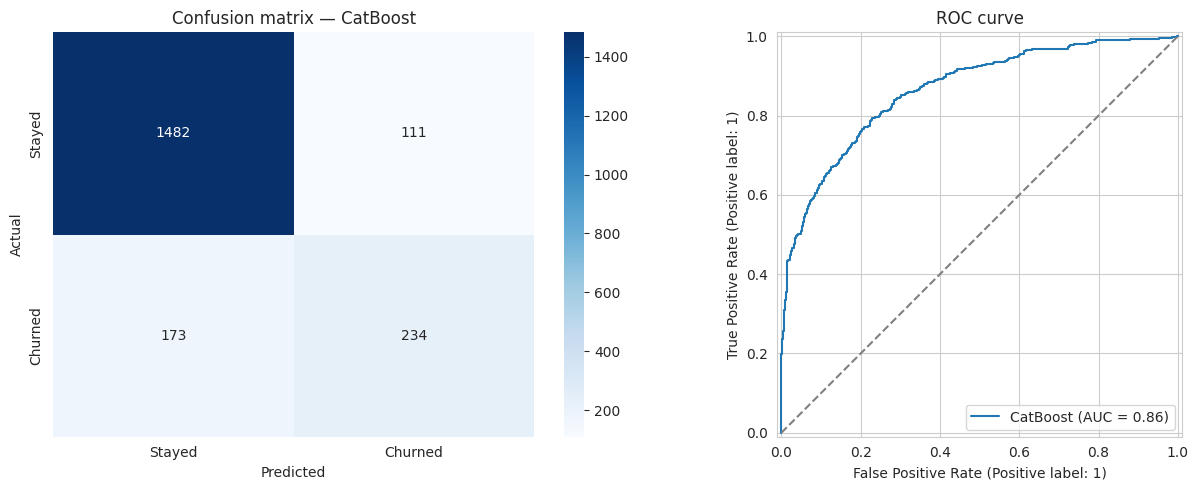

In [15]:
best_name = max(cv_scores, key=lambda k: cv_scores[k][0])
best = fitted[best_name]
print(f"Best model: {best_name}  (CV ROC-AUC {cv_scores[best_name][0]:.3f})\n")

proba = best.predict_proba(X_te)[:, 1]
pred = (proba >= 0.5).astype(int)
print(classification_report(y_te, pred, target_names=["Stayed", "Churned"]))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Stayed","Churned"], yticklabels=["Stayed","Churned"])
ax[0].set_title(f"Confusion matrix — {best_name}"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
RocCurveDisplay.from_predictions(y_te, proba, ax=ax[1], name=best_name)
ax[1].plot([0,1],[0,1], "--", color="gray"); ax[1].set_title("ROC curve")
plt.tight_layout(); plt.show()

### 10d. What drives churn — feature importance

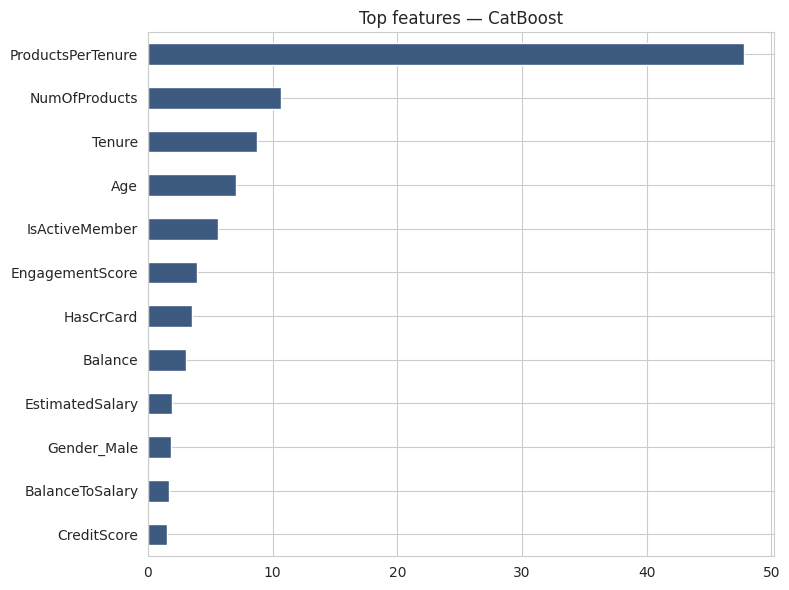

In [16]:
if hasattr(best, "feature_importances_"):
    imp = pd.Series(best.feature_importances_, index=feature_names).sort_values()
    plt.figure(figsize=(8, 6))
    imp.tail(12).plot(kind="barh", color="#3D5A80")
    plt.title(f"Top features — {best_name}"); plt.tight_layout(); plt.show()
else:
    print(f"{best_name} has no single feature_importances_ (it's an ensemble of ensembles).")

## 11. Save the model artifact for the API

In [17]:
import joblib, os
os.makedirs("../api", exist_ok=True)
joblib.dump({"model": best, "features": feature_names, "model_name": best_name},
            "../api/churn_model.joblib")
print(f"Saved ../api/churn_model.joblib  ({best_name})")

Saved ../api/churn_model.joblib  (CatBoost)


## 12. Conclusions & business recommendations

**Modelling.** All boosting models cluster around **ROC-AUC ≈ 0.85**, with **CatBoost**
edging ahead on cross-validated performance and the stacking ensemble a close second —
a useful result: the extra complexity of stacking buys very little here, so the single
gradient-boosting model is the sensible deployment choice (faster, simpler, easier to
explain). SMOTE was applied strictly inside the training folds, so these scores are honest.

**Business.** Three levers, in order of usefulness:
1. **Re-engage inactive customers** — the most actionable driver; inactivity roughly
   doubles churn risk and can be moved with outreach.
2. **Investigate the 3–4 product segment** — its very high churn is counter-intuitive and
   likely signals mis-sold bundles worth auditing.
3. **A Germany-specific retention review** — the country gap points to a local problem
   (pricing, competition, or service) rather than a product one.

**What I'd want next (data not in this set):** timestamps (is churn seasonal / tied to fee
changes?), complaint history, and *which* products the high-product-count customers hold.